In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
gpd.read_file(rf"/data/susanket/zip.geojson")

,IDField,RG_NAME,Sample,geometry
0,00001,Alaska,5,"MULTIPOLYGON (((-157.38337 61.00054, -157.3575..."
1,00002,Alaska,5,"MULTIPOLYGON (((-144.98559 68.50133, -144.9618..."
2,00003,Alaska,5,"MULTIPOLYGON (((-153.32517 58.8511, -153.31762..."
3,00004,Alaska,5,"MULTIPOLYGON (((-153.31676 58.85635, -153.3097..."
4,00005,Alaska,5,"POLYGON ((-153.65861 60.04403, -153.6799 60.04..."
...,...,...,...,...
32152,99925,Alaska,5,"MULTIPOLYGON (((-132.96471 55.62679, -132.9570..."
32153,99926,Alaska,5,"MULTIPOLYGON (((-131.56929 55.28673, -131.5690..."
32154,99927,Alaska,5,"MULTIPOLYGON (((-133.61181 56.35692, -133.6100..."
32155,99929,Alaska,5,"MULTIPOLYGON (((-132.0666 56.71394, -132.06988..."


In [ ]:
import numpy as np
import geopandas as gpd
import duckdb
import pyarrow as pa
from shapely.geometry import shape
import zipfile
import json
import os

def filter_embeddings_by_state(
    npy_path: str, 
    zip_geom_path: str, 
    state_geojson_path: str, 
    output_parquet_path: str
):
    print("Loading state boundary...")
    # Load the state boundary (assumes standard GeoJSON)
    state_gdf = gpd.read_file(state_geojson_path)
    # Dissolve to handle multi-polygon states cleanly and grab the geometry
    state_geom = state_gdf.unary_union

    print("Loading numpy embeddings...")
    # Load embeddings (Shape: [N, embedding_dim])
    embeddings = np.load(npy_path)
    
    print("Reading geometry from zip file...")
    # Read the geometry file directly from the zip without fully extracting to disk
    geoms = []
    gdf = gpd.read_file(zip_geom_path)
    geoms = gdf.geometry.to_list()
                
    # Ensure our aligned sequences match in length
    assert len(geoms) == len(embeddings), f"Mismatch: {len(embeddings)} embeddings vs {len(geoms)} geometries."

    print("Performing spatial filter (finding intersections)...")
    # Filter indices where the geometry intersects or is contained within the state
    valid_indices = []
    filtered_wkt = []
    
    for idx, geom in enumerate(geoms):
        if geom.intersects(state_geom):
            valid_indices.append(idx)
            # Convert to Well-Known Text (WKT) for efficient Parquet/DuckDB handling
            filtered_wkt.append(geom.wkt)

    if not valid_indices:
        print("No geometries found within the provided state boundary.")
        return

    print(f"Found {len(valid_indices)} intersecting features. Slicing embeddings...")
    # Slice the numpy array using our valid indices
    filtered_embeddings = embeddings[valid_indices]
    
    # Convert numpy embedding lists to PyArrow format to preserve multidimensional array structure
    # This stores the embedding as a true fixed-size or variable-size list column in Parquet
    embedding_list = filtered_embeddings.tolist()

    print("Creating Arrow Table...")
    # Create an Arrow table combining the WKT geometry and the embeddings
    table = pa.Table.from_arrays(
        [
            pa.array(filtered_wkt, type=pa.string()),
            pa.array(embedding_list, type=pa.list_(pa.float32()))
        ],
        names=['geometry_wkt', 'embedding']
    )

    print("Writing to highly-compressed Parquet via DuckDB...")
    # Use DuckDB to convert the WKT strings into native geo parquet geometry format if desired,
    # or write out a clean, compressed Arrow table natively.
    db = duckdb.connect()
    db.register('temp_table', table)
    
    # Optimize Parquet storage with ZSTD compression
    db.execute(f"""
        COPY temp_table TO '{output_parquet_path}' 
        (FORMAT PARQUET, COMPRESSION 'ZSTD');
    """)
    
    print(f"Success! Saved filtered dataset to {output_parquet_path}")

# --- Example Usage ---
if __name__ == "__main__":
    # Replace these paths with your actual files
    INPUT_NPY = rf"/data/susanket/mmdfm/embeddings/zip_nofusion.npy"
    INPUT_ZIP = rf"/data/susanket/zip.geojson"        # Contains the aligned geojson file
    STATE_GEOJSON = rf"/home/susanket/query-earth/california.geojson"    # Your target state boundary
    OUTPUT_PARQUET = rf"/data/susanket/queryearth/california-demo-emb.parquet"
    
    filter_embeddings_by_state(INPUT_NPY, INPUT_ZIP, STATE_GEOJSON, OUTPUT_PARQUET)

Loading state boundary...
Loading numpy embeddings...
Reading geometry from zip file...


/tmp/ipykernel_1681932/980704963.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  state_geom = state_gdf.unary_union


Performing spatial filter (finding intersections)...
Found 1832 intersecting features. Slicing embeddings...
Creating Arrow Table...
Writing to highly-compressed Parquet via DuckDB...
Success! Saved filtered dataset to /data/susanket/queryearth/california-demo-emb.parquet


In [11]:
gdf = gpd.read_parquet(rf"/data/susanket/queryearth/california-demo-emb.parquet")

In [12]:
gdf

,IDField,RG_NAME,Sample,geometry,embedding
0,00012,California,5,"POLYGON ((-120.84352 40.24962, -120.84358 40.2...","[2.7063486576080322, 2.6732640266418457, 21.29..."
1,00016,California,5,"POLYGON ((-118.44021 35.55794, -118.43846 35.5...","[6.837795257568359, 6.711771011352539, 20.0517..."
2,00017,California,5,"POLYGON ((-118.77502 37.46305, -118.77447 37.4...","[2.7063486576080322, 2.6732640266418457, 21.29..."
3,00018,California,5,"POLYGON ((-118.81778 34.56244, -118.81779 34.5...","[2.7063486576080322, 2.6732640266418457, 21.29..."
4,00019,California,5,"POLYGON ((-119.99861 40.77159, -119.99855 40.7...","[2.9996142387390137, 17.96994400024414, 10.385..."
...,...,...,...,...,...
1827,97627,Oregon,5,"POLYGON ((-122.05929 42.76058, -122.06053 42.7...","[4.121634483337402, 3.5503804683685303, 3.2685..."
1828,97630,Oregon,5,"POLYGON ((-120.09259 42.23133, -120.09264 42.2...","[6.9924468994140625, 5.161343097686768, 2.2721..."
1829,97632,Oregon,5,"POLYGON ((-121.47235 42.08869, -121.47233 42.0...","[4.76713752746582, 6.223043918609619, 4.276858..."
1830,97633,Oregon,5,"POLYGON ((-121.5112 42.08311, -121.51106 42.08...","[3.7079923152923584, 3.993297576904297, 2.3565..."


In [8]:
import numpy as np
import geopandas as gpd
from shapely.geometry import shape
import json

def create_state_geoparquet(
    npy_path: str, 
    zip_geojson_path: str, 
    state_geojson_path: str, 
    output_geoparquet_path: str
):
    print("Loading state boundary...")
    state_gdf = gpd.read_file(state_geojson_path)
    # Dissolve state features into a single unified geometry for clean intersection checks
    state_geom = state_gdf.unary_union

    print("Loading numpy embeddings...")
    embeddings = np.load(npy_path)
    
    print("Parsing ZIP codes GeoJSON...")
    with open(zip_geojson_path, 'r') as f:
        zip_data = json.load(f)
        
    features = zip_data['features']
    
    # Quick sanity check to ensure 1:1 alignment between geometries and embeddings
    assert len(features) == len(embeddings), \
        f"Mismatch: {len(embeddings)} embeddings vs {len(features)} GeoJSON features."

    print("Performing spatial filtering...")
    valid_indices = []
    filtered_geometries = []
    filtered_properties = [] # Captures existing attributes (e.g., ZIP code string, names)

    for idx, feature in enumerate(features):
        geom = shape(feature['geometry'])
        
        # Check if the ZIP code geometry intersects with the target state boundary
        if geom.intersects(state_geom):
            valid_indices.append(idx)
            filtered_geometries.append(geom)
            filtered_properties.append(feature.get('properties', {}))

    if not valid_indices:
        print("No ZIP codes found intersecting the provided state boundary.")
        return

    print(f"Found {len(valid_indices)} matching ZIP codes. Slicing embeddings...")
    # Slice our aligned numpy array using the valid spatial indices
    filtered_embeddings = embeddings[valid_indices]
    
    # Convert numpy subarray to a list of lists so GeoPandas can store it as a list-type column
    embedding_list = filtered_embeddings.tolist()

    print("Building GeoDataFrame...")
    # Initialize the GeoDataFrame using the filtered properties and geometries
    gdf = gpd.GeoDataFrame(filtered_properties, geometry=filtered_geometries)
    
    # Append the multi-dimensional embeddings as a clean array column
    gdf['embedding'] = embedding_list
    
    # Ensure the coordinate reference system (CRS) matches standard GeoJSON WGS84
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)

    print(f"Writing to native GeoParquet at: {output_geoparquet_path}")
    # Write directly to GeoParquet using pyarrow backend with ZSTD compression
    gdf.to_parquet(
        output_geoparquet_path, 
        index=False, 
        compression='zstd', 
        schema_version='1.0.0' # Ensures compatibility with modern spatial data engines
    )
    
    print(f"Success! Processed dataset size: {gdf.shape[0]} rows.")

# --- Example Usage ---
if __name__ == "__main__":
    INPUT_NPY = rf"/data/susanket/mmdfm/embeddings/zip_nofusion.npy"
    INPUT_ZIP = rf"/data/susanket/zip.geojson"        # Contains the aligned geojson file
    STATE_GEOJSON = rf"/home/susanket/query-earth/california.geojson"    # Your target state boundary
    OUTPUT_PARQUET = rf"/data/susanket/queryearth/california-demo-emb.parquet"
    
    create_state_geoparquet(INPUT_NPY, INPUT_ZIP, STATE_GEOJSON, OUTPUT_PARQUET)

Loading state boundary...
Loading numpy embeddings...
Parsing ZIP codes GeoJSON...


/tmp/ipykernel_1681932/196622190.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  state_geom = state_gdf.unary_union


Performing spatial filtering...
Found 1832 matching ZIP codes. Slicing embeddings...
Building GeoDataFrame...
Writing to native GeoParquet at: /data/susanket/queryearth/california-demo-emb.parquet
Success! Processed dataset size: 1832 rows.


In [4]:
from io import BytesIO
import geopandas as gpd
from PIL import Image
import requests
from shapely.geometry import Point, box

service_url = (
    "https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/export"
)
lat, lon = 34.86830242577879, -120.43328579029456

# 1. Create a 100m buffer around the point (roughly using decimal degrees division)
buffered_geom = Point(lon, lat).buffer(1000 / 111 / 1000)

# 2. Convert to a GeoSeries with the correct CRS, then reproject the entire box to EPSG:3857
bbox_series = gpd.GeoSeries([buffered_geom], crs="EPSG:4326").to_crs("EPSG:3857")

# 3. Extract the reprojected bounding box coordinates
xmin_3857, ymin_3857, xmax_3857, ymax_3857 = bbox_series.bounds.iloc[0]

# Calculate a valid pixel width and height (e.g., 1 meter per pixel resolution)
width = int(xmax_3857 - xmin_3857)
height = int(ymax_3857 - ymin_3857)

export_params = {
    "bbox": f"{xmin_3857},{ymin_3857},{xmax_3857},{ymax_3857}",
    "bboxSR": "3857",
    "size": f"{width},{height}",
    "imageSR": "3857",
    "format": "png",
    "transparent": "true",
    "f": "image",
}

import time
a=time.time()
response = requests.get(service_url, params=export_params)
print(time.time()-a)

# Debugging check: If it fails, print the error text from ArcGIS instead of crashing PIL
if response.status_code == 200:
    try:
        image = Image.open(BytesIO(response.content))
        # image.show()  # Opens the successfully downloaded PNG
    except Exception as e:
        print("ArcGIS returned text/error instead of an image:")
        print(response.text)
else:
    print(f"HTTP Error: {response.status_code}")

19.20740246772766


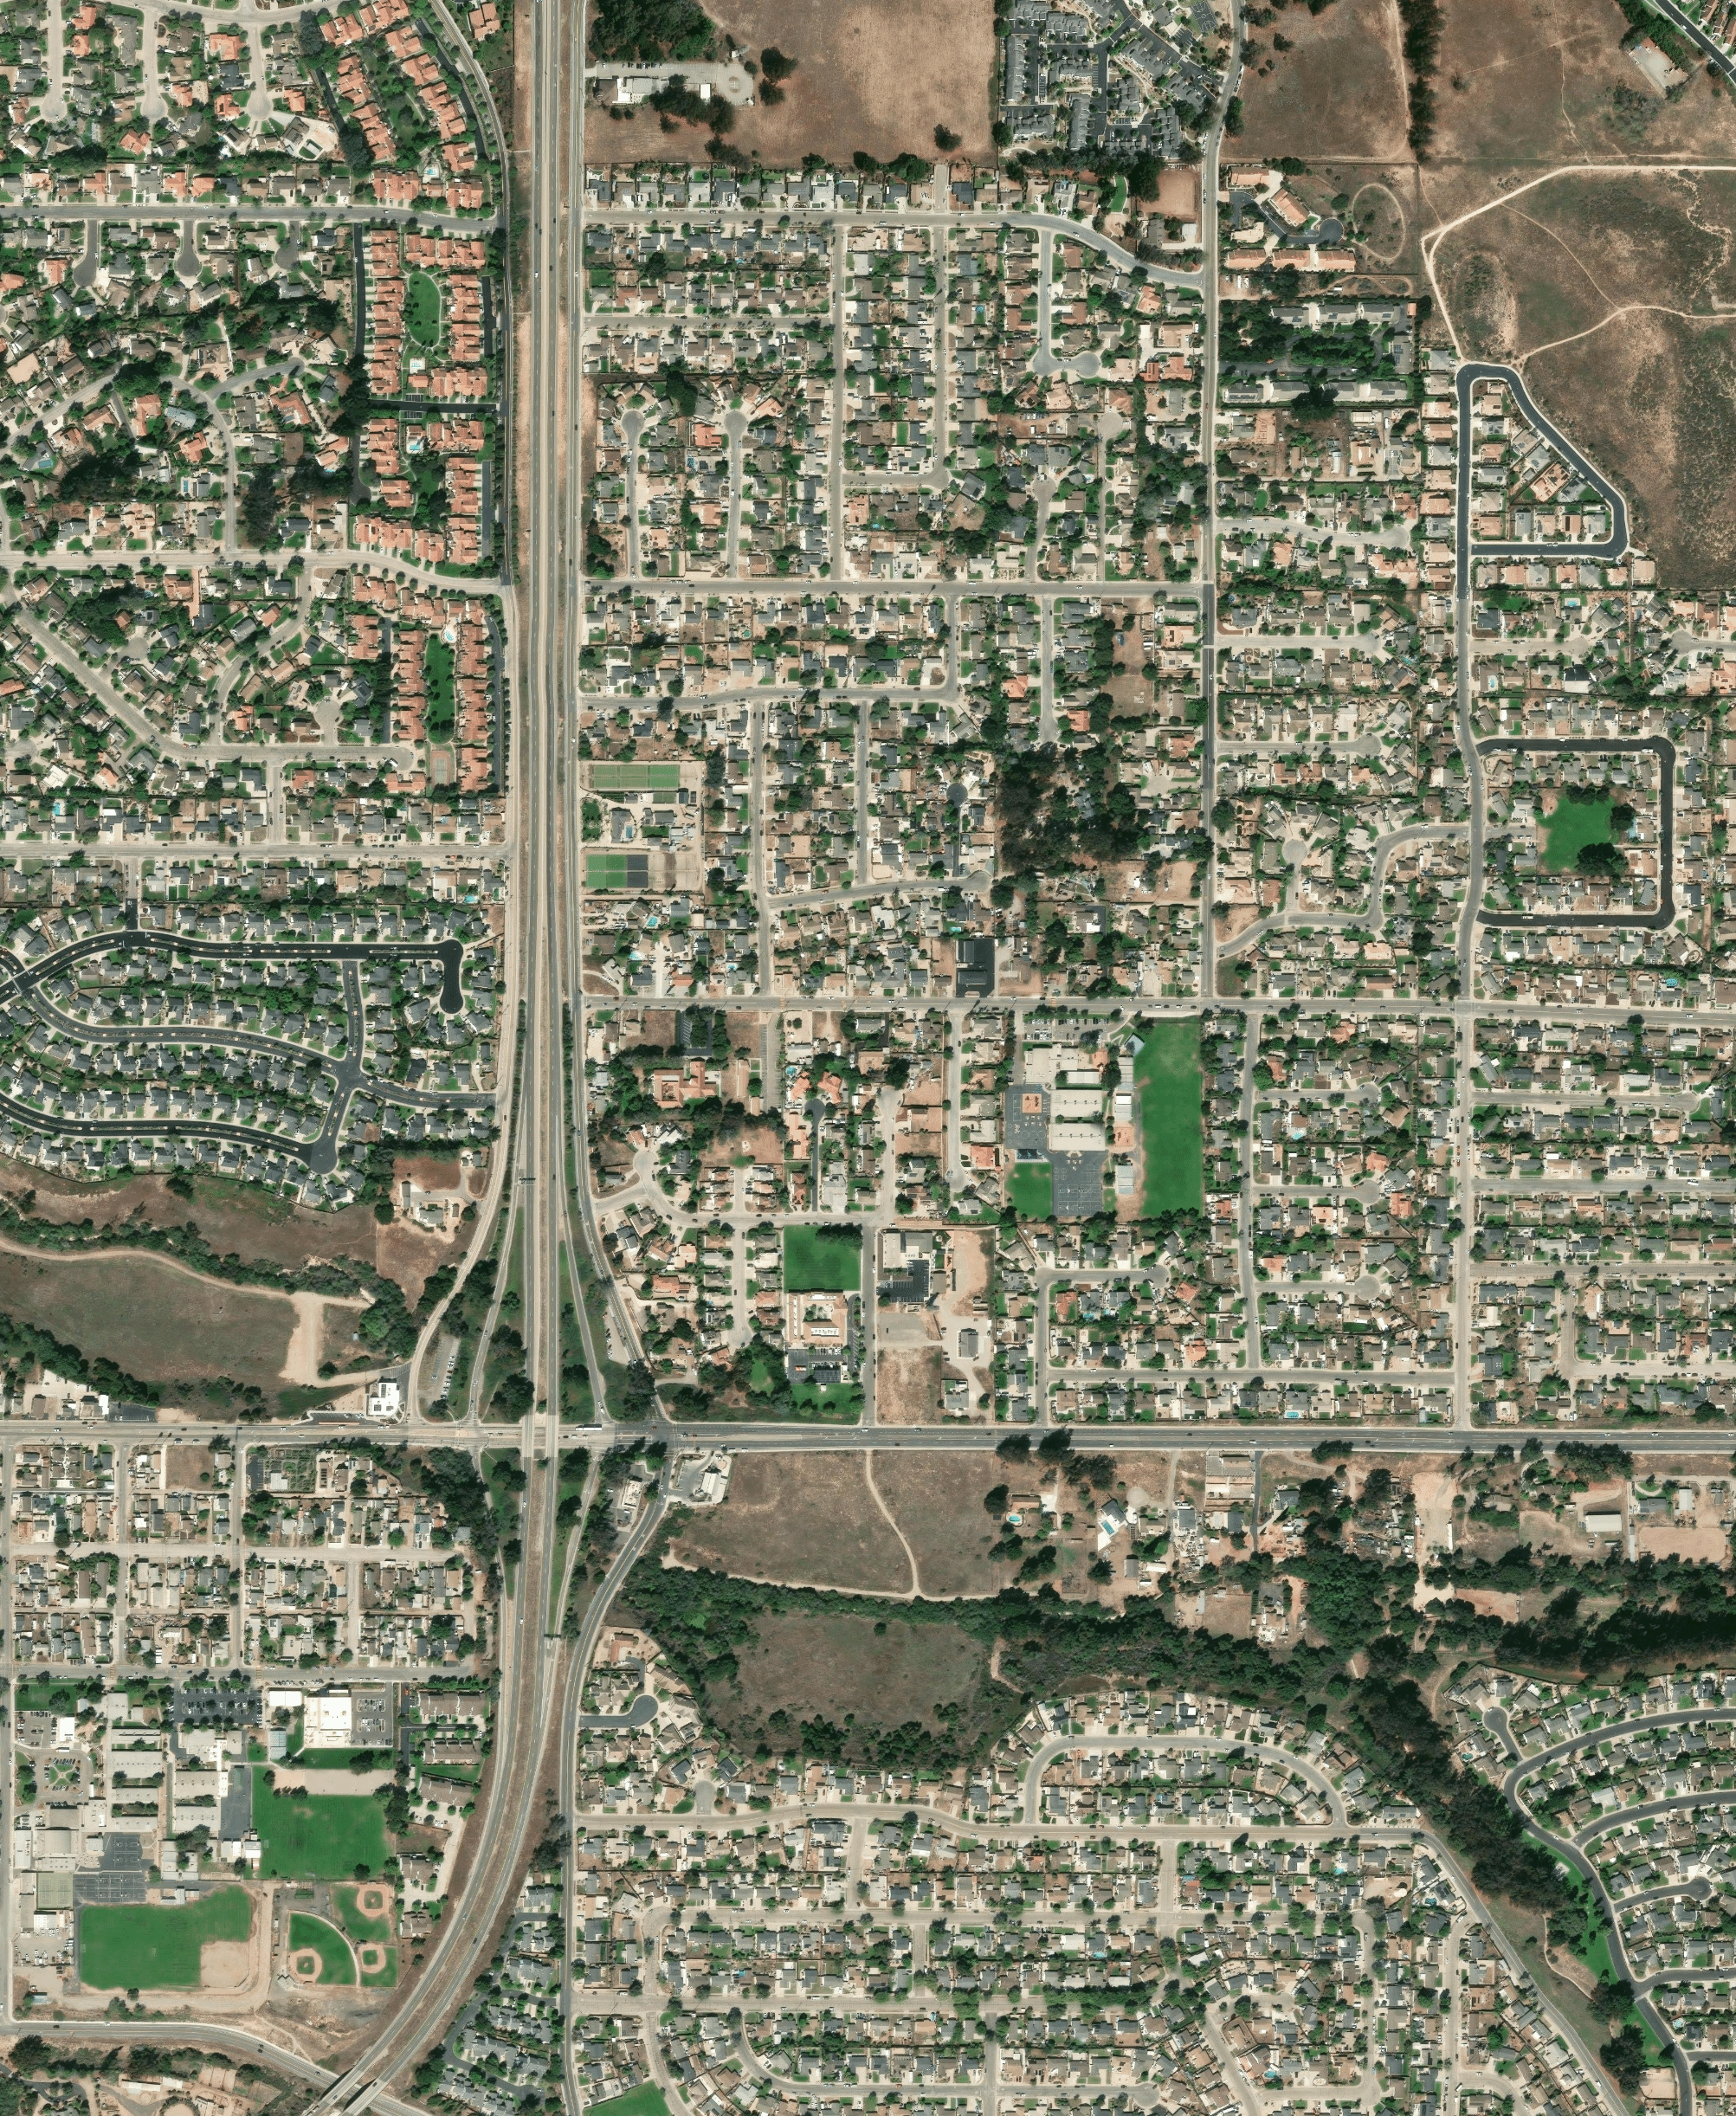

In [5]:
image.show()

In [3]:
from mapminer.miners import ESRIBaseMapMiner

miner = ESRIBaseMapMiner()
ds = miner.fetch(34.86830242577879, -120.43328579029456, radius=100)

In [1]:
import os
from io import BytesIO
import queue
from concurrent.futures import ThreadPoolExecutor
import geopandas as gpd
import numpy as np
from PIL import Image
import requests
from shapely.geometry import Point
import torch
import open_clip
import tqdm

# --- CONFIGURATION ---
GRID_SHAPEFILE = rf"/data/susanket/queryearth\california_grid.shp"
OUTPUT_DIR = "./embedding_results"
CHECKPOINT_INTERVAL = 100  # Save data to disk every N files
SERVICE_URL = "https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/export"
EMBEDDING_DIM = 768       # ViT-L-14 output dimension

# Thread Optimization
MAX_WORKERS = 16  # Number of parallel CPU threads downloading images simultaneously

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

FILE_PATHS = {
    "full": {
        "embs": os.path.join(OUTPUT_DIR, "embeddings_full_embs.dat"),
        "coords": os.path.join(OUTPUT_DIR, "embeddings_full_coords.dat")
    },
    "tile4": {
        "embs": os.path.join(OUTPUT_DIR, "embeddings_tile4_embs.dat"),
        "coords": os.path.join(OUTPUT_DIR, "embeddings_tile4_coords.dat")
    },
    "tile100": {
        "embs": os.path.join(OUTPUT_DIR, "embeddings_tile100_embs.dat"),
        "coords": os.path.join(OUTPUT_DIR, "embeddings_tile100_coords.dat")
    }
}

# --- INITIALIZE OPEN_CLIP ---
print(f"Loading CLIP model on {device}...")
model, _, preprocess = open_clip.create_model_and_transforms('ViT-L-14', pretrained='laion2b_s32b_b82k')
model = model.to(device).eval()

# --- HELPER FUNCTIONS ---

def get_arcgis_image(lat, lon, radius_meters=1000):
    """Fetches an image centered at lat/lon with a given radius."""
    buffered_geom = Point(lon, lat).buffer(radius_meters / 111 / 1000)
    bbox_series = gpd.GeoSeries([buffered_geom], crs="EPSG:4326").to_crs("EPSG:3857")
    xmin_3857, ymin_3857, xmax_3857, ymax_3857 = bbox_series.bounds.iloc[0]

    width, height = 1000, 1000

    export_params = {
        "bbox": f"{xmin_3857},{ymin_3857},{xmax_3857},{ymax_3857}",
        "bboxSR": "3857",
        "size": f"{width},{height}",
        "imageSR": "3857",
        "format": "png",
        "transparent": "true",
        "f": "image",
    }

    try:
        response = requests.get(SERVICE_URL, params=export_params, timeout=30)
        if response.status_code == 200:
            if b"error" in response.content or b"Exception" in response.content:
                return None
            return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception:
        pass
    return None

def download_worker(idx, lat, lon, result_queue):
    """Worker task executed concurrently by the thread pool."""
    img = get_arcgis_image(lat, lon, radius_meters=1000)
    result_queue.put((idx, lat, lon, img))

def tile_image(image, grid_size):
    """Divides an image into grid_size x grid_size equal tiles."""
    img_w, img_h = image.size
    tile_w, tile_h = img_w // grid_size, img_h // grid_size
    tiles = []
    for i in range(grid_size):
        for j in range(grid_size):
            box = (j * tile_w, i * tile_h, (j + 1) * tile_w, (i + 1) * tile_h)
            tiles.append(image.crop(box))
    return tiles

def extract_embeddings(pil_images, model, preprocess, batch_size=32):
    """Batches PIL Images and extracts normalized CLIP embeddings."""
    if not pil_images:
        return np.array([])
    embeddings = []
    for i in range(0, len(pil_images), batch_size):
        batch_imgs = pil_images[i:i+batch_size]
        tensor_imgs = torch.stack([preprocess(img) for img in batch_imgs]).to(device)
        with torch.no_grad(), torch.cuda.amp.autocast():
            feat = model.encode_image(tensor_imgs)
            feat /= feat.norm(dim=-1, keepdim=True)
            embeddings.append(feat.cpu().numpy())
    return np.vstack(embeddings)

# --- MAIN RUNNER ---

def main():
    print("Reading grid shapefile...")
    grid_gdf = gpd.read_file(GRID_SHAPEFILE)
    if grid_gdf.crs != "EPSG:4326":
        grid_gdf = grid_gdf.to_crs("EPSG:4326")
    
    centroids = grid_gdf.geometry.centroid
    total_records = len(grid_gdf)
    print(f"Total grid cells to process: {total_records}")

    state_file = os.path.join(OUTPUT_DIR, "processed_count.txt")
    start_idx = 0
    if os.path.exists(state_file):
        with open(state_file, "r") as f:
            start_idx = int(f.read().strip())
        print(f"Resuming pipeline starting from index: {start_idx}")

    shapes = {
        "full": {"embs": (total_records, EMBEDDING_DIM), "coords": (total_records, 2)},
        "tile4": {"embs": (total_records * 4, EMBEDDING_DIM), "coords": (total_records * 4, 2)},
        "tile100": {"embs": (total_records * 100, EMBEDDING_DIM), "coords": (total_records * 100, 2)}
    }

    mmaps = {}
    for key in ["full", "tile4", "tile100"]:
        mmaps[key] = {
            "embs": np.memmap(FILE_PATHS[key]["embs"], dtype="float32", mode="w+" if start_idx == 0 else "r+", shape=shapes[key]["embs"]),
            "coords": np.memmap(FILE_PATHS[key]["coords"], dtype="float32", mode="w+" if start_idx == 0 else "r+", shape=shapes[key]["coords"])
        }

    cache = {
        "full": {"embs": [], "coords": []},
        "tile4": {"embs": [], "coords": []},
        "tile100": {"embs": [], "coords": []}
    }
    
    pending_count = 0
    result_queue = queue.Queue(maxsize=MAX_WORKERS * 2)

    # 1. Start ThreadPoolExecutor for background downloads
    print(f"Spawning concurrent download pool using {MAX_WORKERS} workers...")
    executor = ThreadPoolExecutor(max_workers=MAX_WORKERS)
    
    # Pre-submit initial tasks to populate the pipeline queue
    current_submit_idx = start_idx
    def refill_queue():
        nonlocal current_submit_idx
        while current_submit_idx < total_records and not result_queue.full():
            p = centroids.iloc[current_submit_idx]
            executor.submit(download_worker, current_submit_idx, p.y, p.x, result_queue)
            current_submit_idx += 1

    refill_queue()

    # 2. Main Consumer Loop (Runs GPU inference synchronously)
    for expected_idx in tqdm.tqdm(range(start_idx, total_records)):
        # Refill download queue at every step iteration
        refill_queue()
        
        # Pull downloaded images from the queue
        idx, lat, lon, img = result_queue.get()
        
        # Handle index mismatches if threads finish slightly out of order
        # (Though memmap handles indexing via explicit array assignments, we track it linearly)
        if img is None:
            cache["full"]["embs"].append(np.zeros(EMBEDDING_DIM))
            cache["full"]["coords"].append([lat, lon])
            cache["tile4"]["embs"].extend([np.zeros(EMBEDDING_DIM)] * 4)
            cache["tile4"]["coords"].extend([[lat, lon]] * 4)
            cache["tile100"]["embs"].extend([np.zeros(EMBEDDING_DIM)] * 100)
            cache["tile100"]["coords"].extend([[lat, lon]] * 100)
        else:
            # Resolution 1: Full View
            emb_full = extract_embeddings([img], model, preprocess)
            cache["full"]["embs"].append(emb_full[0])
            cache["full"]["coords"].append([lat, lon])

            # Resolution 2: 4 Tiles
            tiles_4 = tile_image(img, grid_size=2)
            embs_4 = extract_embeddings(tiles_4, model, preprocess)
            cache["tile4"]["embs"].extend(embs_4)
            cache["tile4"]["coords"].extend([[lat, lon]] * 4)

            # Resolution 3: 100 Tiles
            tiles_100 = tile_image(img, grid_size=10)
            embs_100 = extract_embeddings(tiles_100, model, preprocess)
            cache["tile100"]["embs"].extend(embs_100)
            cache["tile100"]["coords"].extend([[lat, lon]] * 100)

        pending_count += 1

        # Checkpoint: Flush cache to disk allocation files
        if pending_count >= CHECKPOINT_INTERVAL or expected_idx == total_records - 1:
            chunk_start_idx = expected_idx - pending_count + 1
            
            mmaps["full"]["embs"][chunk_start_idx:expected_idx+1] = cache["full"]["embs"]
            mmaps["full"]["coords"][chunk_start_idx:expected_idx+1] = cache["full"]["coords"]

            mmaps["tile4"]["embs"][chunk_start_idx*4:(expected_idx+1)*4] = cache["tile4"]["embs"]
            mmaps["tile4"]["coords"][chunk_start_idx*4:(expected_idx+1)*4] = cache["tile4"]["coords"]

            mmaps["tile100"]["embs"][chunk_start_idx*100:(expected_idx+1)*100] = cache["tile100"]["embs"]
            mmaps["tile100"]["coords"][chunk_start_idx*100:(expected_idx+1)*100] = cache["tile100"]["coords"]

            for key in mmaps:
                mmaps[key]["embs"].flush()
                mmaps[key]["coords"].flush()

            for key in cache:
                cache[key]["embs"].clear()
                cache[key]["coords"].clear()
                
            pending_count = 0
            
            with open(state_file, "w") as f:
                f.write(str(expected_idx + 1))

    # Shutdown thread execution resources safely
    executor.shutdown(wait=True)

    # --- FINAL CONVERSION STEP ---
    print("\nProcessing finished. Packing binary blocks into final 3 compressed NPZ files...")
    for key in ["full", "tile4", "tile100"]:
        out_npz = os.path.join(OUTPUT_DIR, f"embeddings_{key}.npz")
        final_embs = np.memmap(FILE_PATHS[key]["embs"], dtype="float32", mode="r", shape=shapes[key]["embs"])
        final_coords = np.memmap(FILE_PATHS[key]["coords"], dtype="float32", mode="r", shape=shapes[key]["coords"])
        
        np.savez_compressed(out_npz, embeddings=final_embs, centroids=final_coords)
        
        del final_embs, final_coords
        os.remove(FILE_PATHS[key]["embs"])
        os.remove(FILE_PATHS[key]["coords"])

    if os.path.exists(state_file):
        os.remove(state_file)

    print(f"Success! Output datasets stored in {OUTPUT_DIR}.")

if __name__ == "__main__":
    main()

/data/susanket/conda/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/susanket/conda/envs/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading CLIP model on cpu...
Reading grid shapefile...


DataSourceError: /data/susanket/queryearth\california_grid.shp: No such file or directory

In [1]:
import numpy as np

data = np.load(rf"/data/susanket/queryearth/embedding_results/embeddings_full.npy")

FileNotFoundError: [Errno 2] No such file or directory: '/data/susanket/queryearth/embedding_results/embeddings_full.npy'

In [2]:
import geopandas as gpd

gpd.read_file(rf"/data/susanket/queryearth/california_grid.geojson")


,FID,geometry
0,0,"POLYGON ((-13855274.7299 4922930.6171, -138572..."
1,1,"POLYGON ((-13855274.7299 4924930.6171, -138572..."
2,2,"POLYGON ((-13855274.7299 4926930.6171, -138572..."
3,3,"POLYGON ((-13855274.7299 4928930.6171, -138572..."
4,4,"POLYGON ((-13855274.7299 4930930.6171, -138572..."
...,...,...
169581,169581,"POLYGON ((-12705274.7299 4064930.6171, -127072..."
169582,169582,"POLYGON ((-12705274.7299 4066930.6171, -127072..."
169583,169583,"POLYGON ((-12705274.7299 4068930.6171, -127072..."
169584,169584,"POLYGON ((-12705274.7299 4070930.6171, -127072..."


In [1]:
import numpy as np

np.load(rf"/data/susanket/queryearth/embedding_results3/embeddings_full.npz")

NpzFile '/data/susanket/queryearth/embedding_results3/embeddings_full.npz' with keys: embeddings, centroids

In [2]:
import os
import geopandas as gpd
import numpy as np

# --- CONFIGURATION (Must match your original script) ---
GRID_SHAPEFILE = "/data/susanket/queryearth/ca_grid/california_grid.shp"
OUTPUT_DIR = "/data/susanket/queryearth/embedding_results3"
EMBEDDING_DIM = 768

FILE_PATHS = {
    "full": {
        "embs": os.path.join(OUTPUT_DIR, "embeddings_full_embs.dat"),
        "coords": os.path.join(OUTPUT_DIR, "embeddings_full_coords.dat")
    },
    "tile4": {
        "embs": os.path.join(OUTPUT_DIR, "embeddings_tile4_embs.dat"),
        "coords": os.path.join(OUTPUT_DIR, "embeddings_tile4_coords.dat")
    },
    "tile100": {
        "embs": os.path.join(OUTPUT_DIR, "embeddings_tile100_embs.dat"),
        "coords": os.path.join(OUTPUT_DIR, "embeddings_tile100_coords.dat")
    }
}

def main():
    print("Reading grid shapefile to determine total record allocations...")
    grid_gdf = gpd.read_file(GRID_SHAPEFILE)
    total_records = len(grid_gdf)
    print(f"Total reference grid cells: {total_records}")

    # Build the shape matrix definitions exactly as before
    shapes = {
        "full": {"embs": (total_records, EMBEDDING_DIM), "coords": (total_records, 2)},
        "tile4": {"embs": (total_records * 4, EMBEDDING_DIM), "coords": (total_records * 4, 2)},
        "tile100": {"embs": (total_records * 100, EMBEDDING_DIM), "coords": (total_records * 100, 2)}
    }

    print("\nPacking raw binary blocks into compressed NPZ distributions...")
    for key in ["full", "tile4", "tile100"]:
        out_npz = os.path.join(OUTPUT_DIR, f"embeddings_{key}.npz")
        
        # Verify the underlying binary chunks actually exist before opening
        if not os.path.exists(FILE_PATHS[key]["embs"]) or not os.path.exists(FILE_PATHS[key]["coords"]):
            print(f"Skipping key [{key}]: Native data matrices not found.")
            continue
            
        print(f"-> Extracting and compressing: {key}...")
        
        # Read directly from the disk memory map
        final_embs = np.memmap(FILE_PATHS[key]["embs"], dtype="float32", mode="r", shape=shapes[key]["embs"])
        final_coords = np.memmap(FILE_PATHS[key]["coords"], dtype="float32", mode="r", shape=shapes[key]["coords"])
        
        # Export out to compressed archive format
        np.savez_compressed(out_npz, embeddings=final_embs, centroids=final_coords)
        print(f"   Successfully generated: {out_npz}")
        
        # Close out memory-map arrays completely
        del final_embs, final_coords
        
        # Remove massive source raw binary payloads
        try:
            os.remove(FILE_PATHS[key]["embs"])
            os.remove(FILE_PATHS[key]["coords"])
            print(f"   Cleared old binary payloads for: {key}")
        except Exception as e:
            print(f"   Warning: Could not remove temporary binary files: {e}")

    # Remove the state file tracker if it still lingers
    state_file = os.path.join(OUTPUT_DIR, "processed_count.txt")
    if os.path.exists(state_file):
        os.remove(state_file)
        print("\nCleaned up pipeline state tracking index file.")

    print(f"\nAll operations finished successfully! Data stored safely in {OUTPUT_DIR}.")

if __name__ == "__main__":
    main()

Reading grid shapefile to determine total record allocations...
Total reference grid cells: 169586

Packing raw binary blocks into compressed NPZ distributions...
Skipping key [full]: Native data matrices not found.
Skipping key [tile4]: Native data matrices not found.
-> Extracting and compressing: tile100...
   Successfully generated: /data/susanket/queryearth/embedding_results3/embeddings_tile100.npz
   Cleared old binary payloads for: tile100

Cleaned up pipeline state tracking index file.

All operations finished successfully! Data stored safely in /data/susanket/queryearth/embedding_results3.


In [1]:
import geopandas as gpd

gdf = gpd.read_file(rf"/data/susanket/mobclip/data/Hex7.geojson")

DataSourceError: /data/susanket/mobclip/data/Hex7.geojson: No such file or directory

In [3]:
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x

In [4]:
gdf

,FID,index,geometry,lat,lon
0,0,1,"POLYGON ((-19697871.163 6731983.086, -19694923...",6.737277e+06,-1.970103e+07
1,1,2,"POLYGON ((-19697664.199 6721623.316, -19694719...",6.726913e+06,-1.970082e+07
2,2,3,"POLYGON ((-19734504.232 6733230.372, -19731569...",6.738514e+06,-1.973768e+07
3,3,4,"POLYGON ((-19725457.399 6738119.257, -19722517...",6.743408e+06,-1.972863e+07
4,4,5,"POLYGON ((-19734747.983 6743604.841, -19731810...",6.748893e+06,-1.973793e+07
...,...,...,...,...,...
261324,261324,261325,"POLYGON ((-7681934.925 5991466.656, -7687729.0...",5.986136e+06,-7.684112e+06
261325,261325,261326,"POLYGON ((-7711697.212 6011796.893, -7717506.6...",6.006440e+06,-7.713859e+06
261326,261326,261327,"POLYGON ((-7703717.632 6018083.601, -7709532.5...",6.012724e+06,-7.705887e+06
261327,261327,261328,"POLYGON ((-7677638.669 5962243.397, -7683409.1...",5.956939e+06,-7.679810e+06


In [5]:
gdf.to_parquet("/data/susanket/hex6.parquet")

In [ ]:
import os
import time
from io import BytesIO
import concurrent.futures
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
from PIL import Image
from shapely.geometry import Point
import pyarrow as pa
import pyarrow.parquet as pq
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoModel
from tqdm import tqdm

# --- Configuration ---
INPUT_PARQUET = r"/data/susanket/hex6.parquet"
OUTPUT_PARQUET = r"/data/susanket/hex6-dino.parquet"
MODEL_NAME = "facebook/dinov2-large"
BATCH_SIZE = 1024  # Adjust based on your VRAM
NUM_WORKERS = 80   # Data loading workers
MAX_DOWNLOAD_THREADS = 50  # Network requests in parallel

# --- Helper Function: ArcGIS Imagery Downloader ---
def download_single_image(lat, lon):
    """Fetches a 100m buffered satellite image from ArcGIS for a given lat/lon."""
    service_url = "https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/export"
    try:
        # Create a 100m buffer roughly via decimal degrees division
        buffered_geom = Point(lon, lat).buffer(1000 / 111 / 1000)
        bbox_series = gpd.GeoSeries([buffered_geom], crs="EPSG:4326").to_crs("EPSG:3857")
        xmin_3857, ymin_3857, xmax_3857, ymax_3857 = bbox_series.bounds.iloc[0]

        width = int(xmax_3857 - xmin_3857)
        height = int(ymax_3857 - ymin_3857)

        export_params = {
            "bbox": f"{xmin_3857},{ymin_3857},{xmax_3857},{ymax_3857}",
            "bboxSR": "3857",
            "size": f"{width},{height}",
            "imageSR": "3857",
            "format": "png",
            "transparent": "true",
            "f": "image",
        }
        
        response = requests.get(service_url, params=export_params, timeout=15)
        if response.status_code == 200:
            img = Image.open(BytesIO(response.content)).convert("RGB")
            return img
    except Exception as e:
        pass
    return None

# --- PyTorch Dataset Setup ---
class ImageryDinoDataset(Dataset):
    """Custom dataset that takes pre-loaded/downloaded PIL images and processes them."""
    def __init__(self, images, processor):
        self.images = images
        self.processor = processor

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if img is None:
            # Return dummy tensor if image download failed (handled later in batch processing)
            dummy_pixel = torch.zeros((3, 224, 224), dtype=torch.float32)
            return dummy_pixel, False
        
        inputs = self.processor(images=img, return_tensors="pt")
        return inputs.pixel_values.squeeze(0), True

# --- Main Pipeline ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load Model and Processor
    processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME).to(device)
    model.eval()
    
    if torch.cuda.device_count() > 1:
        print(f"Utilizing {torch.cuda.device_count()} GPUs via DataParallel.")
        model = torch.nn.DataParallel(model)

    # Read base data
    print("Reading coordinates from Parquet...")
    df = pd.read_parquet(INPUT_PARQUET)
    
    # Pre-allocate container for images
    downloaded_images = [None] * len(df)
    
    # 1. Multi-threaded Network I/O Download Phase
    print(f"Downloading satellite imagery using {MAX_DOWNLOAD_THREADS} parallel threads...")
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_DOWNLOAD_THREADS) as executor:
        futures = {
            executor.submit(download_single_image, row['lat'], row['lon']): idx 
            for idx, row in df.iterrows()
        }
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Downloading"):
            idx = futures[future]
            downloaded_images[idx] = future.result()

    # 2. PyTorch High-Throughput Embedding Phase
    dataset = ImageryDinoDataset(downloaded_images, processor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

    all_cls_embeddings = []

    print("Generating DINOv2 CLS Embeddings...")
    with torch.no_grad():
        for pixel_values, valid_flags in tqdm(dataloader, desc="DINO Inference"):
            pixel_values = pixel_values.to(device)
            
            # Forward pass through Dino
            outputs = model(pixel_values=pixel_values)
            # Gather CLS tokens (index 0)
            cls_tokens = outputs.last_hidden_state[:, 0, :].detach().cpu().numpy()
            
            # Map items back, assigning None vectors to failed downloads
            for i, is_valid in enumerate(valid_flags):
                if is_valid.item():
                    # Cast to float16 to preserve file sizes in Parquet format
                    all_cls_embeddings.append(cls_tokens[i].astype(np.float16).tolist())
                else:
                    all_cls_embeddings.append(None)

    # Add embeddings back to original DataFrame and write to Disk
    df['dino_cls'] = all_cls_embeddings
    
    print(f"Saving final dataset to {OUTPUT_PARQUET}...")
    table = pa.Table.from_pandas(df)
    pq.write_table(table, OUTPUT_PARQUET)
    print("Pipeline completed successfully.")

if __name__ == "__main__":
    main()

/data/susanket/conda/envs/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Using device: cpu


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Utilizing 4 GPUs via DataParallel.
Reading coordinates from Parquet...


Downloading: 100%|██████████| 261329/261329 [00:07<00:00, 34280.05it/s] 


Generating DINOv2 CLS Embeddings...


DINO Inference:   0%|          | 0/256 [00:00<?, ?it/s]/data/susanket/conda/envs/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
DINO Inference:   0%|          | 1/256 [01:23<5:56:33, 83.89s/it]

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet(rf"/data/susanket/queryearth/data/hex7-skyclip.parquet")

In [2]:
df

,index,lat,lon,emb,res
0,872800400ffffff,40.259014,-124.249031,"[0.0003178127, 0.151408, -0.0076732384, 0.0567...",low
1,872800400ffffff,40.269485,-124.263870,"[0.04083478, 0.10535317, 0.0011840771, -0.0055...",high
2,872800400ffffff,40.269485,-124.260574,"[0.037603438, 0.1030301, -0.0054812036, -0.031...",high
3,872800400ffffff,40.269485,-124.257278,"[0.046413325, 0.14064896, -0.013777126, 0.0082...",high
4,872800400ffffff,40.269485,-124.253975,"[0.039919857, 0.13908908, -0.011028062, -0.002...",high
...,...,...,...,...,...
7576106,87485bccbffffff,32.755993,-114.569038,"[0.029909205, 0.04565061, 0.028523577, -0.0359...",high
7576107,87485bccbffffff,32.755993,-114.565796,"[0.03336948, 0.07187309, 0.020980982, -0.02370...",high
7576108,87485bccbffffff,32.755993,-114.562553,"[0.033073716, 0.04053808, 0.028802482, -0.0577...",high
7576109,87485bccbffffff,32.755993,-114.559303,"[0.027565634, 0.038990524, 0.030248486, -0.040...",high


In [12]:
data = df[df['res']=="high"]['emb'].to_numpy()

In [13]:
data = np.stack(data)

In [14]:
data

array([[ 0.04083478,  0.10535317,  0.00118408, ...,  0.00169441,
         0.00598902,  0.0250717 ],
       [ 0.03760344,  0.1030301 , -0.0054812 , ..., -0.00975762,
        -0.01516435,  0.03512783],
       [ 0.04641332,  0.14064896, -0.01377713, ...,  0.01114719,
         0.01370552, -0.00303128],
       ...,
       [ 0.03307372,  0.04053808,  0.02880248, ..., -0.00092762,
         0.02547329,  0.03329415],
       [ 0.02756563,  0.03899052,  0.03024849, ..., -0.0127532 ,
         0.01485478,  0.0400302 ],
       [ 0.01661867,  0.02242553,  0.03794396, ...,  0.00619056,
         0.0217866 , -0.00358694]], shape=(7501100, 768), dtype=float32)

In [17]:
loc = df[df['res']=="high"][['lat', 'lon']].to_numpy()

In [18]:
loc

array([[  40.269485, -124.26387 ],
       [  40.269485, -124.260574],
       [  40.269485, -124.25728 ],
       ...,
       [  32.755993, -114.56255 ],
       [  32.755993, -114.5593  ],
       [  32.755993, -114.55606 ]], shape=(7501100, 2), dtype=float32)

In [19]:
np.savez_compressed(rf"/data/susanket/queryearth/data/hex7-skyclip-high.npz", emb = data, locations = loc)

In [1]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd

parquet_path = "/data/susanket/queryearth/vlm_captions_1M.parquet"
recovered_tables = []

try:
    # Open the file as a generic PyArrow file handle
    with pa.memory_map(parquet_path, mode='r') as source:
        file_reader = pq.ParquetFile(source)
        num_row_groups = file_reader.num_row_groups
        print(f"File metadata lists {num_row_groups} total row groups.")
        
        # Read group by group until it hits the corrupted section
        for i in range(num_row_groups):
            try:
                row_group_table = file_reader.read_row_group(i)
                recovered_tables.append(row_group_table)
            except Exception as group_err:
                print(f"\nStopped reading at Row Group {i} due to corruption: {group_err}")
                break
                
except Exception as file_err:
    print(f"Could not initialize file reader: {file_err}")

# Combine whatever survived and save it to a clean file
if recovered_tables:
    combined_table = pa.concat_tables(recovered_tables)
    recovered_df = combined_table.to_pandas()
    
    # Save the healthy portion to a new, non-corrupted Parquet file
    fixed_path = "/data/susanket/queryearth/vlm_captions_1M_recovered.parquet"
    recovered_df.to_parquet(fixed_path, index=False)
    
    print(f"\n🎉 Success! Recovered {len(recovered_df)} rows out of the broken file.")
    print(f"Saved healthy data to: {fixed_path}")
else:
    print("\n❌ Zero row groups could be recovered. The file structural damage is too severe.")

Could not initialize file reader: Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.

❌ Zero row groups could be recovered. The file structural damage is too severe.


In [ ]:
python query-earth/vlm/train.py --parquet_path /data/susanket/queryearth/data/vlm_captions_1M.parquet --val_parquet_path /data/susanket/queryearth/data/vlm_captions_val.parquet --image_col image_bytes --caption_col caption --clip_name openai/clip-vit-base-patch32 --proj_dim 128 --batch_size 1024 --verbose 1 --epochs 500  --lr 1e-4 --output_dir /data/susanket/queryearth/runs/128dim-unfrozen-1mil

In [29]:
import pandas as pd


df1 = pd.read_parquet(rf"E:\Data\query-earth\vlm_captions_2.parquet")

In [6]:
df2 = pd.read_parquet(rf"E:\Data\query-earth\vlm_captions_2.parquet")
df3 = pd.read_parquet(rf"E:\Data\query-earth\git-10mil\git_10m_1000000.parquet")
df4 = pd.read_parquet(rf"E:\Data\query-earth\git-10mil\git_10m_1000000_random.parquet")


In [7]:
merged_df = pd.concat([df1, df2, df3, df4])

In [4]:
merged_df.sample(5)

,sample_id,lat,lon,image_size,caption,image_bytes
33047,362576,36.816418,-93.048485,224,"This aerial view captures a densely vegetated,...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
81232,873184,37.769550,15.116571,224,"This aerial view captures a winding, unpaved r...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
6894,84542,36.506218,-94.047691,224,"This aerial view captures a rugged, arid lands...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
20224,226653,45.493011,0.737079,224,This aerial view captures a rural landscape fe...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
43607,464053,30.622877,-102.884407,112,"This aerial view depicts a densely scattered, ...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...


In [8]:
len(merged_df)

1794797

In [9]:
merged_df.to_parquet(rf"E:\Data\query-earth\git-10mil\train_vlm.parquet")

In [3]:
from transformers import BertTokenizer, BertModel
import torch

model_name = "prajjwal1/bert-tiny"

# Load BERT classes explicitly
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

text = "This is a test sentence for inference."
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

with torch.no_grad():
    outputs = model(**inputs)

print(f"Output shape: {outputs.last_hidden_state.shape}")

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Output shape: torch.Size([1, 10, 128])


model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

In [4]:
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-1.5597,  0.5547, -3.4471,  ..., -1.0033, -0.2819, -0.4578],
         [-2.3763,  1.0205, -0.1733,  ..., -2.3161, -0.2056, -0.3239],
         [-2.1062,  0.8453, -0.5661,  ..., -1.9115, -0.3880, -0.6896],
         ...,
         [-1.7476,  0.3455, -0.2844,  ..., -1.7375, -0.1480,  0.4981],
         [-0.8130,  0.7139, -0.1947,  ..., -1.7819, -0.5337, -0.1324],
         [-2.0527,  1.0126,  0.2459,  ..., -1.6219, -0.5595,  0.9759]]]), pooler_output=tensor([[-9.9999e-01, -1.7103e-02, -9.9696e-01, -7.7985e-01, -9.9478e-01,
          2.0184e-01, -9.8060e-01, -8.9698e-01, -6.2819e-02, -1.0646e-02,
         -5.7254e-01, -1.8940e-02, -7.4682e-02,  9.9999e-01, -6.3544e-01,
         -8.1965e-01,  8.3673e-01,  1.9660e-01, -9.6281e-01,  1.2387e-01,
          9.6627e-01, -1.4713e-01,  6.6844e-01, -6.9414e-02, -9.9990e-01,
         -8.5804e-02, -9.9980e-01,  7.4552e-01,  9.2180e-01,  3.7664e-02,
         -2.9393e-02,  3.2474e-02, -

In [20]:
import pandas as pd

df = pd.read_parquet(rf"E:\Data\query-earth\git-10mil\git_10m_1000000_random.parquet")

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


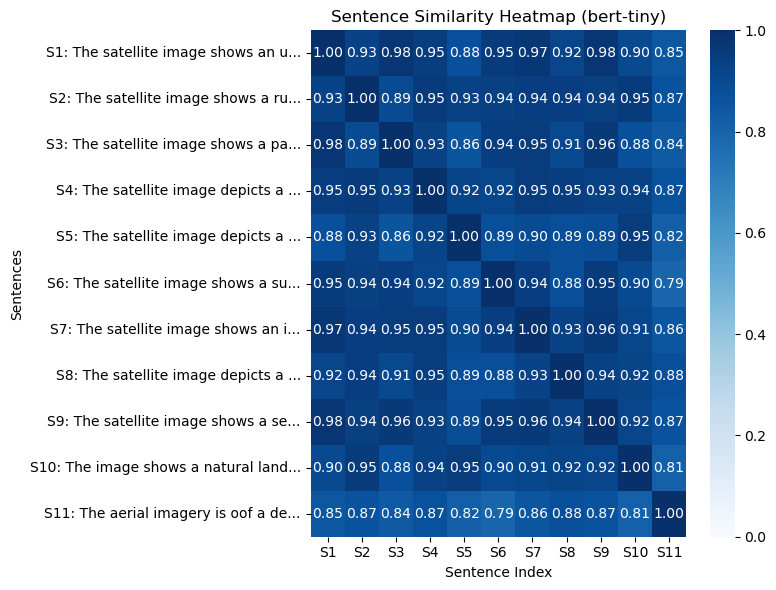

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random
from transformers import BertTokenizer, BertModel

# 1. Load tokenizer and model
model_name = "prajjwal1/bert-tiny"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# 2. Input sentences to compare
sentences = random.sample(list(df.caption), 10) + ["The aerial imagery is oof a densely residential urban setting."]

# 3. Tokenize and extract embeddings
inputs = tokenizer(sentences, return_tensors="pt", truncation=True, padding=True)

with torch.no_grad():
    outputs = model(**inputs)

# Mean Pooling: Average hidden states over token dimensions (masking out padding)
attention_mask = inputs["attention_mask"].unsqueeze(-1)  # Shape: (batch_size, seq_len, 1)
token_embeddings = outputs.last_hidden_state           # Shape: (batch_size, seq_len, hidden_dim)

sum_embeddings = torch.sum(token_embeddings * attention_mask, dim=1)
sum_mask = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
sentence_embeddings = sum_embeddings / sum_mask  # Shape: (batch_size, hidden_dim)

# 4. Compute Cosine Similarity Matrix
# F.cosine_similarity calculates pairwise similarity when normalized
normalized_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.T).numpy()

# 5. Plot Similarity Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[f"S{i+1}" for i in range(len(sentences))],
    yticklabels=[f"S{i+1}: {s[:30]}..." for i, s in enumerate(sentences)],
    vmin=0.0,
    vmax=1.0
)

plt.title("Sentence Similarity Heatmap (bert-tiny)")
plt.xlabel("Sentence Index")
plt.ylabel("Sentences")
plt.tight_layout()
plt.show()

In [7]:
sentence_embeddings.shape

torch.Size([5, 128])

In [22]:
sentences

['The satellite image shows an urban area with a major road running vertically through the center. On the left side of the road, there are several buildings with parking lots, including one large, L-shaped building. On the right side, there is an open area with some vehicles and scattered construction materials. The road has multiple vehicles traveling in both directions. Some greenery is present near the buildings and along the edges of the image.',
 'The satellite image shows a rural landscape with a mix of forested areas and agricultural fields. There are scattered buildings, some with blue roofs, connected by narrow roads. The terrain appears to be hilly with a few clusters of vegetation interspersed among the structures.',
 'The satellite image shows a parking lot with numerous cars parked in rows on the left side. Adjacent to the parking area, there is a road network with multiple lanes and marked traffic lines. A small, rectangular building is situated near the center of the ima

In [35]:
import pandas as pd


df1 = pd.read_parquet(rf"E:\Data\query-earth\git-10mil\git_10m_100.parquet")

In [36]:
import re

import re

def _clean_text(text: str) -> str:
    if not text:
        return ""

    # Preserve leading quotes/asterisks (e.g., '*"', '"')
    wrapper_match = re.match(r'^([\s*"\'\`]*)', text)
    prefix_wrapper = wrapper_match.group(1) if wrapper_match else ""
    core_text = text[len(prefix_wrapper):]

    # Pattern breakdown:
    # 1. Optional leading articles: "this", "the", "a", "an"
    # 2. Optional descriptors: "aerial", "dense", "close-up", etc.
    # 3. Noun: "image", "view", "shot", "photo", "picture", "depiction", etc.
    # 4. Action verb: "shows", "depicts", "captures", "displays", "features", "presents", "illustrates"
    # 5. Optional trailing article: "a", "an", "the"
    intro_pattern = r'^(?:(?:this|the|a|an)\s+)?(?:[\w-]+\s+)?(?:image|view|shot|photo|photograph|picture|graphic|illustration|diagram)\s+(?:shows|depicts|captures|displays|features|presents|illustrates|contains|reveals)\s+(?:(?:a|an|the)\s+)?'

    # Strip prefix phrase (case-insensitive)
    cleaned_core = re.sub(intro_pattern, "", core_text, flags=re.IGNORECASE)

    # Clean up double spaces and trailing edges
    cleaned_core = re.sub(r'\s+', ' ', cleaned_core).strip()

    # Capitalize the new starting word
    if cleaned_core:
        cleaned_core = cleaned_core[0].upper() + cleaned_core[1:]

    return prefix_wrapper + cleaned_core

In [38]:
sentences

['The image depicts a landscape characterized by rugged terrain, with prominent valleys and ridges. The area is primarily covered in green vegetation, interspersed with bare or less vegetated regions. The scene shows a natural landform with no visible man-made structures.',
 'The satellite image shows a region with a mix of green and brown areas. There are large bodies of water visible towards the upper right and left edges. Some patches of white, likely clouds, are present in the central part of the image, casting shadows on the landscape below. The terrain features both vegetated and barren areas.',
 'The satellite image depicts a mountainous terrain with a series of ridges and valleys. The area shows variations in elevation, with some sections appearing more rugged and dark, contrasting with flatter and greenish areas.',
 'The satellite image shows a landscape dominated by brown terrain with scattered patches of darker areas. There are a few small, irregularly shaped bodies of water

In [37]:
sentences = random.sample(list(df1.caption), 10)
for text in sentences:
    print(_clean_text(text))

Landscape characterized by rugged terrain, with prominent valleys and ridges. The area is primarily covered in green vegetation, interspersed with bare or less vegetated regions. The scene shows a natural landform with no visible man-made structures.
Region with a mix of green and brown areas. There are large bodies of water visible towards the upper right and left edges. Some patches of white, likely clouds, are present in the central part of the image, casting shadows on the landscape below. The terrain features both vegetated and barren areas.
Mountainous terrain with a series of ridges and valleys. The area shows variations in elevation, with some sections appearing more rugged and dark, contrasting with flatter and greenish areas.
Landscape dominated by brown terrain with scattered patches of darker areas. There are a few small, irregularly shaped bodies of water dispersed throughout the scene. Linear features indicate the presence of natural formations or watercourses. Vegetation

In [39]:
import torch

# Load the weights into a dictionary
weights = torch.load(rf"D:\dlpk\vlm\SkyCLIP-ViT-L-14.pth", map_location=torch.device('cpu'))

# Look at the layer names (keys)
print(weights.keys())


odict_keys(['cls_token', 'pos_embed', 'patch_embed.proj.weight', 'norm_pre.weight', 'norm_pre.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.qkv.bias', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.fc1.weight', 'blocks.1.mlp.fc1.bias', 'blocks.1.mlp.fc2.weight', 'blocks.1.mlp.fc2.bias', 'blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.qkv.bias', 'blocks.2.attn.proj.weight', 'blocks.2.attn.proj.bias', 'blocks.2.norm2.weight', 'blocks.2.norm2.bias', 'blocks.2.mlp.fc1.weight', 'blocks.2.mlp.fc1.bias', 'blocks.2.mlp.fc2.wei

In [40]:
weights

OrderedDict([('cls_token',
              tensor([[[ 0.0138,  0.2357, -0.1285,  ...,  0.0171, -0.3332, -0.2366]]])),
             ('pos_embed',
              tensor([[[ 0.0019,  0.0479, -0.0149,  ...,  0.0005, -0.0558, -0.0460],
                       [ 0.0114, -0.0413,  0.0357,  ...,  0.0271, -0.0313, -0.0383],
                       [-0.0026, -0.0340, -0.0006,  ...,  0.0216, -0.0294, -0.0423],
                       ...,
                       [-0.0038, -0.0350, -0.0048,  ..., -0.0228, -0.0328, -0.0412],
                       [-0.0046, -0.0360, -0.0026,  ..., -0.0350, -0.0355, -0.0353],
                       [-0.0073, -0.0287, -0.0144,  ..., -0.0202, -0.0272, -0.0360]]])),
             ('patch_embed.proj.weight',
              tensor([[[[ 2.5283e-02,  1.0597e-02,  7.1679e-03,  ...,  2.3423e-02,
                          2.1684e-02,  4.8654e-03],
                        [ 1.3748e-02, -6.2105e-03, -4.8098e-03,  ...,  1.6420e-02,
                          7.0146e-03, -1.3159e-02],
    

In [41]:
for k, v in weights.items():
    print(k, v.shape)

cls_token torch.Size([1, 1, 1024])
pos_embed torch.Size([1, 257, 1024])
patch_embed.proj.weight torch.Size([1024, 3, 14, 14])
norm_pre.weight torch.Size([1024])
norm_pre.bias torch.Size([1024])
blocks.0.norm1.weight torch.Size([1024])
blocks.0.norm1.bias torch.Size([1024])
blocks.0.attn.qkv.weight torch.Size([3072, 1024])
blocks.0.attn.qkv.bias torch.Size([3072])
blocks.0.attn.proj.weight torch.Size([1024, 1024])
blocks.0.attn.proj.bias torch.Size([1024])
blocks.0.norm2.weight torch.Size([1024])
blocks.0.norm2.bias torch.Size([1024])
blocks.0.mlp.fc1.weight torch.Size([4096, 1024])
blocks.0.mlp.fc1.bias torch.Size([4096])
blocks.0.mlp.fc2.weight torch.Size([1024, 4096])
blocks.0.mlp.fc2.bias torch.Size([1024])
blocks.1.norm1.weight torch.Size([1024])
blocks.1.norm1.bias torch.Size([1024])
blocks.1.attn.qkv.weight torch.Size([3072, 1024])
blocks.1.attn.qkv.bias torch.Size([3072])
blocks.1.attn.proj.weight torch.Size([1024, 1024])
blocks.1.attn.proj.bias torch.Size([1024])
blocks.1.norm2

In [42]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

# Load model and processor
model = CLIPModel.from_pretrained("BiliSakura/SkyCLIP-ViT-L-14")
processor = CLIPProcessor.from_pretrained("BiliSakura/SkyCLIP-ViT-L-14")

# Load and process image
image = Image.open("path/to/your/image.jpg")
inputs = processor(
    text=["a photo of a building", "a photo of vegetation", "a photo of water"],
    images=image,
    return_tensors="pt",
    padding=True
)

# Get image-text similarity scores
with torch.inference_mode():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

print(f"Similarity scores: {probs}")


OSError: BiliSakura/SkyCLIP-ViT-L-14 does not appear to have a file named pytorch_model.bin or model.safetensors.

In [43]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

# Add subfolder="transformers" to tell it where to look
model = CLIPModel.from_pretrained("BiliSakura/SkyCLIP-ViT-L-14", subfolder="transformers")
processor = CLIPProcessor.from_pretrained("BiliSakura/SkyCLIP-ViT-L-14", subfolder="transformers")

# Load and process image
image = Image.open("path/to/your/image.jpg")
inputs = processor(
    text=["a photo of a building", "a photo of vegetation", "a photo of water"],
    images=image,
    return_tensors="pt",
    padding=True
)

# Get image-text similarity scores
with torch.inference_mode():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

print(f"Similarity scores: {probs}")


config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

c:\Users\sus14836\AppData\Local\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sus14836\.cache\huggingface\hub\models--BiliSakura--SkyCLIP-ViT-L-14. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] You are using a model of type `clip_vision_model` to instantiate a model of type

transformers/model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPModel LOAD REPORT from: BiliSakura/SkyCLIP-ViT-L-14
Key                                                             | Status     |                                                                                                        
----------------------------------------------------------------+------------+--------------------------------------------------------------------------------------------------------
vision_model.encoder.layers.{12...23}.self_attn.v_proj.weight   | UNEXPECTED |                                                                                                        
vision_model.encoder.layers.{12...23}.layer_norm2.bias          | UNEXPECTED |                                                                                                        
vision_model.encoder.layers.{12...23}.self_attn.k_proj.weight   | UNEXPECTED |                                                                                                        
vision_model.e

RuntimeError: You set `ignore_mismatched_sizes` to `False`, thus raising an error. For details look at the above report!

In [44]:
import torch
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModel

# Load the vision-only model and processor
model = CLIPVisionModel.from_pretrained(
    "BiliSakura/SkyCLIP-ViT-L-14", 
    subfolder="transformers"
)
processor = AutoProcessor.from_pretrained(
    "BiliSakura/SkyCLIP-ViT-L-14", 
    subfolder="transformers"
)

# Load image
image = Image.open("path/to/your/image.jpg")
inputs = processor(images=image, return_tensors="pt")

with torch.inference_mode():
    outputs = model(**inputs)
    
    # [1, 768] normalized visual embedding vector
    image_embeds = outputs.pooler_output 

print("Image embedding shape:", image_embeds.shape)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

ValueError: Unrecognized processing class in BiliSakura/SkyCLIP-ViT-L-14. Can't instantiate a processor, a tokenizer, an image processor, a video processor or a feature extractor for this model. Make sure the repository contains the files of at least one of those processing classes.

In [68]:
import torch
import torch.nn.functional as F
from PIL import Image
import timm
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------------------
# 1. Load the Vision Model from your local .pth file using timm
# ---------------------------------------------------------------------
# The key structure in your .pth matches a standard timm ViT-Large patch14 model
import timm

vision_model = timm.create_model(
    "vit_large_patch14_224",
    pretrained=False,
    num_classes=768,
    patch_size=14,
    img_size=224,
    # Match OpenAI CLIP ViT layout
    no_embed_class=False,
    pre_norm=True,        # Adds norm_pre layer
)

# Load state dict strictly
state_dict = torch.load(r"D:\dlpk\vlm\SkyCLIP-ViT-L-14.pth", map_location="cpu")
vision_model.load_state_dict(state_dict, strict=True)
vision_model = vision_model.to(device).eval()

# Standard Image Preprocessing for ViT-L/14 (224x224)
img_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073], 
        std=[0.26862954, 0.26130258, 0.27577711]
    ),
])

# ---------------------------------------------------------------------
# 2. Load OpenAI / OpenCLIP Text Encoder for matching embeddings
# ---------------------------------------------------------------------
# SkyCLIP was trained on top of OpenAI CLIP ViT-L/14 text representation space
from transformers import CLIPTokenizer, CLIPTextModel

text_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_model = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device).eval()

# ---------------------------------------------------------------------
# 3. Compute Similarity Scores
# ---------------------------------------------------------------------
image_path = rf"E:\Data\query-earth\vlm\eval\data\RSICB128\avenue\avenue(2).tif"
labels = ["building", "vegetation", "water", "tree"]

# Preprocess Image
image = Image.open(image_path).convert("RGB")
img_tensor = img_transform(image).unsqueeze(0).to(device)

# Preprocess Text
text_tokens = text_tokenizer(text=labels, return_tensors="pt", padding=True).to(device)

with torch.inference_mode():
    # Forward pass vision (timm forward handles the head projection to 768)
    image_embeds = vision_model(img_tensor) 
    
    # Forward pass text
    text_outputs = text_model(**text_tokens)
    text_embeds = text_outputs.pooler_output

    # Normalize embedding vectors to unit length
    image_embeds = F.normalize(image_embeds, p=2, dim=-1)
    text_embeds = F.normalize(text_embeds, p=2, dim=-1)

    # Compute cosine similarity and apply CLIP scaling factor (~100)
    logits_per_image = (image_embeds @ text_embeds.T) * 100.0
    probs = logits_per_image.softmax(dim=-1)

print("Class Probabilities:", probs.cpu().numpy())

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.post_layernorm.bias                               | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.

Class Probabilities: [[0.14072223 0.25962564 0.54880196 0.05085015]]


In [86]:
import torch
import torch.nn.functional as F
from PIL import Image
import open_clip
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Instantiate matching ViT-L-14 model architecture
# open_clip.create_model_and_transforms returns (model, preprocess_train, preprocess_val)
model, _, _ = open_clip.create_model_and_transforms('ViT-L-14', pretrained=False)

# 2. Load Checkpoint
ckpt_path = r"D:\dlpk\vlm\RS5M_ViT-L-14.pt"
checkpoint = torch.load(ckpt_path, map_location="cpu")

# Handle checkpoints that nest weights under 'state_dict' or 'model' keys
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
elif isinstance(checkpoint, dict) and "model" in checkpoint:
    state_dict = checkpoint["model"]
else:
    state_dict = checkpoint

# Load visual backbone weights into model.visual (or full model if text keys exist)
try:
    model.visual.load_state_dict(state_dict, strict=True)
except Exception:
    model.load_state_dict(state_dict, strict=False)

model = model.to(device).eval()

# 3. Standard Preprocessing replacement for `get_preprocess(image_resolution=224)`
img_preprocess = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073], 
        std=[0.26862954, 0.26130258, 0.27577711]
    ),
])

# 4. Run inference
tokenizer = open_clip.get_tokenizer('ViT-L-14')

image_path = rf"E:\Data\query-earth\vlm\eval\data\RSICB128\avenue\avenue(2).tif"
labels = ["building", "vegetation", "water", "tree"]

image = Image.open(image_path).convert("RGB")
image_tensor = img_preprocess(image).unsqueeze(0).to(device)
text_tokens = tokenizer(labels).to(device)

with torch.inference_mode():
    # Visual forward pass
    image_features = model.encode_image(image_tensor)
    
    # If using OpenAI text encoder
    text_features = model.encode_text(text_tokens)

    print(image_features.shape, text_features.shape)

    # Normalize vectors
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)

    # Cosine similarity matrix
    logits = (image_features @ text_features.T) * 100.0
    probs = logits.softmax(dim=-1)

print("Similarity scores:", probs.cpu().numpy())

torch.Size([1, 768]) torch.Size([4, 768])
Similarity scores: [[3.2540358e-04 7.4970561e-01 2.0088633e-03 2.4796006e-01]]


In [113]:
import torch
import torch.nn.functional as F
from PIL import Image
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = 'ViT-L-14'
# LAION-2B pre-trained tag
PRETRAINED_TAG = 'laion2b_s32b_b82k' 

# 1. Instantiate open_clip with pre-trained LAION text weights
# This populates model.encode_text with LAION's trained text model
model, _, img_preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, 
    pretrained=PRETRAINED_TAG
)

# 2. Load RS5M custom visual weights over the visual tower
ckpt_path = r"D:\dlpk\vlm\RS5M_ViT-L-14.pt"
checkpoint = torch.load(ckpt_path, map_location="cpu")

if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
elif isinstance(checkpoint, dict) and "model" in checkpoint:
    state_dict = checkpoint["model"]
else:
    state_dict = checkpoint

# Load RS5M visual weights into model.visual
try:
    model.visual.load_state_dict(state_dict, strict=True)
except Exception:
    # Fallback if state dict includes non-visual prefix keys
    model.load_state_dict(state_dict, strict=False)

model = model.to(device).eval()

# 3. Tokenizer paired with LAION model architecture
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

image_path = r"E:\Data\query-earth\vlm\eval\data\RSICB128\avenue\avenue(2).tif"
labels = ["building", "vegetation", "water", "tree"]

image = Image.open(image_path).convert("RGB")
# Use the official transform bundled directly with the LAION config
image_tensor = img_preprocess(image).unsqueeze(0).to(device)
text_tokens = tokenizer(labels).to(device)

with torch.inference_mode():
    image_features = model.encode_image(image_tensor)
    text_features = model.encode_text(text_tokens)

    print(image_features.shape, text_features.shape)

    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)

    # Cosine similarity matrix scaled by model logit scale
    logit_scale = model.logit_scale.exp() if hasattr(model, 'logit_scale') else 100.0
    logits = (image_features @ text_features.T) * logit_scale
    probs = logits.softmax(dim=-1)

print("Similarity scores:", probs.cpu().numpy())

torch.Size([1, 768]) torch.Size([4, 768])
Similarity scores: [[5.3584465e-04 6.5758115e-01 2.2548737e-03 3.3962807e-01]]


In [128]:
with torch.inference_mode():
    image_features = model.forward_intermediates(image_tensor)

In [ ]:
image_features[''].shape

AttributeError: 'dict' object has no attribute 'shape'

In [129]:
with torch.inference_mode():
    # 1. Get intermediate patch features (shape: [B, 1024, H, W] or [B, N, 1024])
    patch_features = model.forward_intermediates(image_tensor)['image_intermediates'][-1]

    # 2. Re-order dimensions if in NCHW format: [B, H, W, 1024]
    if patch_features.ndim == 4:
        patch_features = patch_features.permute(0, 2, 3, 1)

    # 3. Apply the model's linear projection matrix (if using OpenCLIP / timm CLIP)
    # This projects 1024 -> 768
    if hasattr(model, "proj") and model.proj is not None:
        patch_features = patch_features @ model.proj
    elif (
        hasattr(model, "visual")
        and hasattr(model.visual, "proj")
        and model.visual.proj is not None
    ):
        patch_features = patch_features @ model.visual.proj

    # 4. Normalize (CLIP embeddings are typically L2-normalized)
    patch_features = patch_features / patch_features.norm(
        dim=-1, keepdim=True
    )

print("Projected Patch Shape:", patch_features.shape)  # Now ending in 768!

Projected Patch Shape: torch.Size([1, 16, 16, 768])


In [123]:
patch_features.shape

torch.Size([768])

In [1]:
f = {'id': 'chatcmpl-049dd020-350d-4e4d-a758-fd8b1f05ac15', 'object': 'chat.completion', 'created': 1784958962, 'model': 'E:\\Data\\query-earth\\Ministral-3-3B-Reasoning-2512.Q4_K_M.gguf', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': 'Okay, the user is asking what\'s on my mind. Since I\'m an AI, I don\'t have personal thoughts, but I can simulate a response that reflects a human-like thought process.\n\nFirst, I need to consider that the question is about what\'s on my mind, which is a bit abstract. Maybe I can think about the current context or the user\'s possible expectations.\n\nPerhaps I can start by acknowledging the question and then provide a response that reflects a general idea of what might be on my mind, such as processing the user\'s input, maintaining a conversation, or being ready to assist.\n\nLet me try to draft a response that sounds natural and engaging.\n\nHere\'s how I can phrase it:\n\n"I\'m thinking about how to best assist you in this conversation. Maybe it\'s about understanding your needs or ideas and providing helpful information. How can I help you today?"\n\nWait, maybe that\'s a bit too focused on the task. Maybe I can make it more personal-like, but still AI-friendly.\n\nAlternative approach: "I\'m considering the best way to respond to your question. Perhaps it\'s about being ready to provide information or help with whatever you need. How can I assist you today?"\n\nHmm, maybe that\'s a bit too generic. Let me try to make it a bit more engaging.\n\nFinal attempt:\n\n"I\'m thinking about how to best engage with you in this conversation. Maybe it\'s about understanding your interests or the topic you\'d like to discuss. What\'s on your mind today?"\n\nBut perhaps the user is just asking for a casual response, not necessarily about the task. Maybe I can be a bit more open and personal.\n\nWait, perhaps the simplest is to say that I\'m thinking about the user\'s question and how to respond.\n\nLet me try this:\n\n"I\'m thinking about how to best answer your question. Maybe it\'s about understanding the context and providing'}, 'logprobs': None, 'finish_reason': 'length'}], 'usage': {'prompt_tokens': 131, 'completion_tokens': 381, 'total_tokens': 512}}

In [14]:
print(f['choices'][0]['message']['content'])

Okay, the user is asking what's on my mind. Since I'm an AI, I don't have personal thoughts, but I can simulate a response that reflects a human-like thought process.

First, I need to consider that the question is about what's on my mind, which is a bit abstract. Maybe I can think about the current context or the user's possible expectations.

Perhaps I can start by acknowledging the question and then provide a response that reflects a general idea of what might be on my mind, such as processing the user's input, maintaining a conversation, or being ready to assist.

Let me try to draft a response that sounds natural and engaging.

Here's how I can phrase it:

"I'm thinking about how to best assist you in this conversation. Maybe it's about understanding your needs or ideas and providing helpful information. How can I help you today?"

Wait, maybe that's a bit too focused on the task. Maybe I can make it more personal-like, but still AI-friendly.

Alternative approach: "I'm considerin

In [5]:
f.keys(
    
)

dict_keys(['id', 'object', 'created', 'model', 'choices', 'usage'])

In [9]:
f['model']

'E:\\Data\\query-earth\\Ministral-3-3B-Reasoning-2512.Q4_K_M.gguf'

In [15]:
import ollama
ROUTER_SYSTEM_PROMPT = """You are a geospatial query planning assistant. Convert the
user's natural-language request into a JSON pipeline of steps that, executed in
order, answer the query.

Each step has:
  - "operation": one of "geocode", "demo", "vision", "tool"
  - "parameters": object with keys "target", "resolution", "buffer_distance_km"
      - "target": for geocode -> place name.
                  for demo   -> the demographic/socioeconomic text query.
                  for vision -> the visual object/land-use text query.
                  for tool   -> one of "buffer", "union", "intersection", "difference", "add".
      - "resolution": only used for "vision" steps. One of "low", "high".
                       low = ~2km tiles (broad context),
                       high = ~200m tiles (fine detail, small objects). null otherwise.
      - "buffer_distance_km": only used for "tool" steps with target "buffer". null otherwise.
  - "inputs": list of output_variable names this step depends on (empty list if none)
  - "output_variable": a short variable name (e.g. "A", "B", "C_buffered") this
      step's result is stored as, for later steps to reference

Rules:
- "geocode" steps always have empty "inputs" (they start a region from a place name).
- "demo" and "vision" steps take exactly one input: the region they search within.
  If no prior region was established, "inputs" is empty (search the whole study area).
- "tool" steps take one input for "buffer", and two inputs for "union"/"intersection"/
  "difference"/"add" (in that order — for "difference", the result is inputs[0] minus inputs[1]).
- The final step's output_variable must be "FINAL_ANSWER".
- Choose "resolution" for vision steps based on the size of the object being searched for:
  small/fine objects (pools, vehicles, individual structures) -> "high";
  large objects/land-use patterns (forests, farmland, golf courses, large facilities) -> "low".
- **Return ONLY a valid JSON object** of the form {"pipeline_steps": [...]}. No markdown,
  no explanations, no trailing text.
- Do not output any tools or modes like "confirmation" thats not mwentiobned here.

Example 1:
Query: "find suburban neighbourhoods in Texas with backyard swimming pools but no golf courses within 5 kms"
Output:
You should return :
{"pipeline_steps": [
  {"operation": "geocode",
   "parameters": {"target": "Texas", "resolution": null, "buffer_distance_km": null},
   "inputs": [], "output_variable": "A"},
  {"operation": "demo",,
   "parameters": {"target": "suburban neighborhoods", "resolution": null, "buffer_distance_km": null},
   "inputs": ["A"], "output_variable": "B"},
  { "operation": "vision",
   "parameters": {"target": "golf courses", "resolution": "high", "buffer_distance_km": null},
   "inputs": ["A"], "output_variable": "C"},
  { "operation": "tool",
   "parameters": {"target": "buffer", "resolution": null, "buffer_distance_km": 5.0},
   "inputs": ["C"], "output_variable": "C_buffered"},
  {"operation": "tool", "description": "Remove golf-course buffer zones from suburban neighborhoods",
   "parameters": {"target": "difference", "resolution": null, "buffer_distance_km": null},
   "inputs": ["B", "C_buffered"], "output_variable": "D"},
  {"operation": "vision",
   "parameters": {"target": "backyard swimming pools", "resolution": "low", "buffer_distance_km": null},
   "inputs": ["D"], "output_variable": "FINAL_ANSWER"}
]}

**Return ONLY a valid JSON object** of the form {"pipeline_steps": [...]}. Remember the supported ops: {"geocode", "demo", "vision", "tool"}
"""


from ollama import chat

# response = chat(
#     model='ministral-3:3b',
#     messages=[{'role': 'user', 'content': ROUTER_SYSTEM_PROMPT+ "QUERY: find all the farmlands in the Southern LA."}],
# )
# print(response.message.content)

In [17]:
response = chat(
    model="ministral-3:3b",
    format="json",
    options={
        "temperature":0,
        "top_k":1,
        "top_p":1,
        # "num_predict":256
    },
    messages=[
        {"role":"system","content":ROUTER_SYSTEM_PROMPT},
        {"role":"user","content":"QUERY: find all the farmlands in the LA."},
    ],
    keep_alive="30m"
)
print(response.message.content)

{"pipeline_steps": [
  {
    "operation": "geocode",
    "parameters": {"target": "Los Angeles, California", "resolution": null, "buffer_distance_km": null},
    "inputs": [],
    "output_variable": "A"
  },
  {
    "operation": "vision",
    "parameters": {"target": "farmlands", "resolution": "low", "buffer_distance_km": null},
    "inputs": ["A"],
    "output_variable": "FINAL_ANSWER"
  }
]}


In [2]:
import geopandas as gpd

gdf = gpd.read_parquet(rf"D:\Code\query-earth\dlpk\embeddings\poi.parquet")

In [3]:
gdf

,amenity,name,geometry
0,bank,Chase,POINT (-122.02073 36.97937)
1,toilets,None,POINT (-121.41902 40.68548)
2,drinking_water,None,POINT (-122.24535 37.865)
3,parking,Big Painted Cave Trail Parking,POINT (-121.51228 41.72942)
4,parking,Schonchin Butte Parking,POINT (-121.52534 41.74077)
...,...,...,...
209797,community_centre,Club Lincoln Crossing,POINT (-121.30524 38.87292)
209798,restaurant,Nick's Laguna Beach,POINT (-117.78248 33.5413)
209799,restaurant,Thai Bros,POINT (-117.78259 33.54174)
209800,bench,None,POINT (-117.78279 33.54128)
